# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kevin Teng

**Date:** 9/2/26

In [213]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd

#question 1 part 1
df1 = pd.read_csv('./data/airbnb_hw.csv')

#standarizes prices to just be numbers, removing the $ and , characters
df1["Price"] = df1["Price"].str.replace('$', '')
df1["Price"] = df1["Price"].str.replace(',', '')

#converts prices to numeric values
df1["Price"] = pd.to_numeric(df1["Price"], errors='coerce')

#shows the first 30 values for the Price variable
print(df1["Price"].head(30), "\n")

print(df1["Price"].describe(), "\n")

#sums up the number of missing value
print(df1["Price"].isna().sum(), "\n")

#question 1 part 2
df2 = pd.read_csv('./data/mn_police_use_of_force.csv')

#removes extra spaces from subject_injury  
df2["subject_injury"] = df2["subject_injury"].str.strip()

#standardizes the subject_injury variable to be all lowercase
df2["subject_injury"] = df2["subject_injury"].str.lower()

#sums the number of missing values for the subject_injury variable
missing = df2["subject_injury"].isna().sum()
print("Missing values:", missing, "\n")

#calculates missing proportion
print("Percentage of missing values:", missing/len(df2["subject_injury"]), "\n")

#cross tabulate
print(pd.crosstab(df2["force_type"], df2["subject_injury"].fillna("na")), "\n")


0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
20    125
21    175
22     90
23     40
24     89
25     95
26     99
27    149
28    499
29     99
Name: Price, dtype: int64 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

0 

Missing values: 9848 

Percentage of missing values: 0.7619342359767892 

subject_injury                 na    no   yes
force_type                                   
Baton                           2     0     2
Bodily Force                 7051  1093  1286
Chemical Irritant            1421   131    41
Firearm                         0     2     0
Gun Point Display              27    33    44
Improvised Weapon              74    34    40
Less Lethal         

### Question 1 part 1
I removed the '$' abnd ',' characters in the "Price" variable. The reason for this cleaning decision is to better standarize the values so that each Price is formatted as just numbers. I then use pd.to_numeric to convert potential numbers formatted as strings to a float value. I then used head to get the first 30 values of the dataset, to see if my data cleaning was applied correctly. Although 30 is a small sample size, it helps to get a rough idea if the data is consistent. I then used describe to get a rough breakdown of some vital statistics for the dataset. Mainly, the count shows 30478 and there also appears to be 30478 rows in the csv when manually inspected so every data point should be accounted for. Finally, I summed up all the na values for the Prices variable, which returned 0. This indicates that there are no missing prices in the dataset.

### Question 1 part 2
I applied .strip and .lower to the subject_injury variable to standarize the true/false values to be a consistent for the entire dataset. I then summed up all the rows with na value to find the total number of rows with missing values. Taking the missing values and then dividing it by the length of the dataframe (total number of rows), returns a decimal value of 0.7619342359767892. This suggests that 76.19% of the dataset has a missing value for the subject_injury variable. This is a significant concern since this indicates that more than 3/4 of the subject_injury variable is missing. Subject injury does also seems to not be evenly distributed between the force types. Bodily force, for example, has 7051 missing values which is significantly larger than both yes and no combined for that type of subject injury. Simillar patterns are shown for Chemical Irritant and Taser. Sine categories like Maximal Restraint Technique and Less Lethal have all of their values missing. There are also some with no missing values, like Less Lethal Projectile and Firearm.


In [214]:
df3 = pd.read_excel('./data/GSAF5.xls')
df3.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [215]:
#question 2 part 2
#removes columns that are empty
df3 = df3.dropna(axis=1, how='all')
df3.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
#question 2 part 3
df3["Year"] = pd.to_numeric(df3["Year"], errors='coerce')
print(df3["Year"].unique(), "\n")
df_since_1940 = df3[df3["Year"] >= 1940]
x = df_since_1940["Year"].value_counts().sort_index()
x.plot()
plt.xlabel("Year")
plt.ylabel("Number of Shark Attacks")
plt.title("Number of Shark Attacks per Year Since 1940")
plt.show()

### Question 2 Part 3

Using .unique, we see that the data has a large range. We see some outliers like 1000, 0, and nan which could be representative of placeholders for missing values or errors in data entry. The dataset typically ranges from 1500 to 2026, but with significant gaps in earlier years possibly due to inconsistent record keeping. The line graph shows that since 1940, the number of shark attacks were steadily rising before showing a downward trend until the 1980s. The trend of growing shark attacks resumes in the 1980s, and peaks in the mid 2010s, before seeing a sharp decline in recent years.


['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


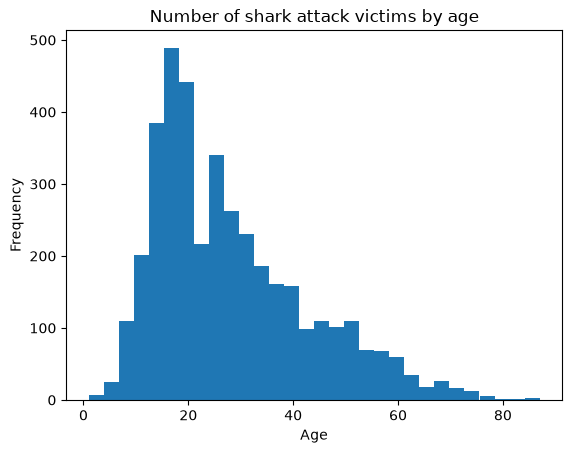

In [ ]:
#question 2 part 4

#get all unique values for the Age variable
print(df3["Age"].unique())

#change number to numeric
df3["Age"] = pd.to_numeric(df3["Age"], errors='coerce')

#filter out rows where Age is missing
df_with_age = df3[df3["Age"].notna()]

#cleaned ages
print(df_with_age["Age"].unique(), "\n")

df_with_age["Age"].plot(kind='hist', bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Number of shark attack victims by age")
plt.show()

In [ ]:
#question 2 part 5

#standarizes the sex variable to be all uppercase and removes extra spaces
df_sex = df3["Sex"].str.strip().str.upper()
df_sex = df_sex[df_sex.isna() == False]
num_male = (df_sex == "M").sum()
print("Proportion of male victims:", num_male/len(df_sex))



Proportion of male victims: 0.8736809909772136


### Question 2 Part 5

Around 87.37% of shark attack victims are male

In [ ]:
#question 2 part 6
df_type = df3["Type"].str.strip().str.title()
print(df_type.unique(), "\n")

df_type = df_type.where(df_type.isin(["Provoked", "Unprovoked"]), "Unknown")
print(df_type.value_counts(), "\n")
num_unprovoked = (df_type == "Unprovoked").sum()
print("Proportion of unprovoked attacks:", num_unprovoked/len(df_type), "\n")


<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'Watercraft',        'Sea Disaster',                   nan,
                   '?',         'Unconfirmed',          'Unverified',
             'Invalid', 'Under Investigation',                'Boat']
Length: 12, dtype: str 

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

Proportion of unprovoked attacks: 0.7394969790642124 



### Question 2 Part 6

Approximately 73.95% of shark attacks are unprovoked

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**  5d6dd8e30e6091af022aa2af460c503e5396e4d0
- **AI tool and model used:** Google Gemini 3.1 Pro

### *Prompts used

1. Suggest a list of changes for phase 1 of this notebook and explain the reason for each change, what the change does, why it is necessary
2. what are some other suggestions, particularly for question 2 in phase 1 of the notebook. Make sure to still explain the reason for each change, what the change does, why it is necessary

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

### 1. Improve Age variable extraction (Question 2, Part 4)

- **The Change:** Instead of immediately using `pd.to_numeric(df["Age"], errors='coerce')`, use a regular expression like `df["Age"].str.extract(r'(\d+)')` to pull out digits before converting to a numeric type.
- **What it does:** It captures the numerical portion of messy strings such as "20s", "40+", or "9 months" and converts them into 20, 40, and 9 respectively.
- **Why it is necessary:** Coercing errors directly to NaN destroys a significant amount of salvageable data. Extracting the digits first provides a much more accurate histogram and statistical representation of the victims' ages.

### 2. Explicitly define regex behavior for Price cleaning (Question 1, Part 1)

- **The Change:** Add `regex=False` to your string replacement functions, changing the code to `df["Price"].str.replace('$', '', regex=False)`.
- **What it does:** It explicitly tells Pandas to look for the literal string $ rather than treating it as a regular expression character.
- **Why it is necessary:** Because $ is a special end-of-string character in regular expressions, running this method without `regex=False` will trigger a FutureWarning in modern versions of Pandas and may cause unexpected behavior.

### 3. Persist NA handling in the DataFrame (Question 1, Part 2)

- **The Change:** Apply `.fillna("na")` directly to the `df["subject_injury"]` column to overwrite the data, rather than only doing it temporarily inside the `pd.crosstab()` call.
- **What it does:** It permanently replaces all missing values in the `subject_injury` column with the string "na" (or "unknown") in memory.
- **Why it is necessary:** The prompt specifically asks you to clean the variable and handle the NAs. Persisting this change ensures that any subsequent operations on this DataFrame will automatically use the cleaned, NA-handled data.

### 4. Convert the `Year` column to a nullable integer type (Question 2, Part 3)

- **The Change:** Update the numeric conversion to cast the type directly: `df["Year"] = pd.to_numeric(df["Year"], errors='coerce').astype('Int64')`.
- **What it does:** It converts the years from floats (e.g., `2026.0`) into Pandas' nullable integer format (e.g., `2026`), while safely maintaining the `NaN` values for unparseable data.
- **Why it is necessary:** Years are inherently discrete integers, but standard Pandas converts columns with missing data into floats. Forcing the `Int64` type cleans up your x-axis on visualizations and prevents floating-point inaccuracies during analysis.

### 5. Use built-in Pandas methods for dropping missing values (Question 2, Part 5)

- **The Change:** Replace your manual boolean mask `df_sex[df_sex.isna() == False]` with the built-in method: `df_sex = df_sex.dropna()`.
- **What it does:** It achieves the exact same result—removing all `NaN` values from your `df_sex` Series—but does so using a single, optimized function call.
- **Why it is necessary:** While checking for `== False` works, using `.dropna()` is the idiomatic, Pythonic standard. It makes your code highly readable and relies on underlying C-optimized routines for better performance on large data structures.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | Converting messy string using a single regular expression may not be sufficient and can cause more problems. One of the provided examples by the AI suggest changing 9 months to 9, implying 9 years old. This is a significant deviation from the actual age. Furthermore, generalizing strings like 20s to 20 and 40+ to 40 may make the data more inaccurate by treating the approximate values as exact ages. Verified by manually reviewing the values with .unique() to find other examples like '17 & 35' that would cause similalr issues (would become 1735). |
| 2 | Accept  | Explicitly setting regex = False makes the intended behavior clear that it is replace the '$' symbol and not a regular expression. Used df["Price"].head() to checdk that there aren't any extraneous symbos in the dataframe|
| 3 | Accept  | This change ensures that the data cleaning is permanently saved to the dataframe instead of having to reapply the filter everytime. Verified using df["subject_injury].isna().sum which returned 0. This indicates that the dataframe no longer has any na values for the variable subject_injury. |
| 4 | Reject  | Converting year to Int64 is not needed since it is standard for pandas to represent years as floats when there are NaN values. In addition, the float still represents the year correctly and converting the years to int does not meaningfully chnage the accuracy of the data visualization. Verified by looking at previous df["Year].unique output, the .0 from using a float rather than an int had no effect|
| 5 | Accept  | Using .dropna() is more concise and improves readability. Verified by coimparing the values of df_sex[df_sex.isna() == False] and df_sex.dropna(), with both returning 0.8736809909772136|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

#Question 1 part 1 revised
df1 = pd.read_csv('./data/airbnb_hw.csv')
#standarizes prices to just be numbers, removing the $ and , characters
df1["Price"] = df1["Price"].str.replace('$', '', regex=False)
df1["Price"] = df1["Price"].str.replace(',', '', regex=False)

#converts prices to numeric values
df1["Price"] = pd.to_numeric(df1["Price"], errors='coerce')

#shows the first 30 values for the Price variable
print(df1["Price"].head(30), "\n")

print(df1["Price"].describe(), "\n")

#sums up the number of missing value
print(df1["Price"].isna().sum(), "\n")



0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
20    125
21    175
22     90
23     40
24     89
25     95
26     99
27    149
28    499
29     99
Name: Price, dtype: int64 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

0 



In [ ]:
#Question 1 part 2 revised
#removes extra spaces from subject_injury  
df2["subject_injury"] = df2["subject_injury"].str.strip()

#standardizes the subject_injury variable to be all lowercase
df2["subject_injury"] = df2["subject_injury"].str.lower()

#sums the number of missing values for the subject_injury variable
missing = df2["subject_injury"].isna().sum()

#calculates missing proportion
print("Percentage of missing values:", missing/len(df2["subject_injury"]), "\n")
print(df2["subject_injury"].isna().sum())
df2["subject_injury"] = df2["subject_injury"].fillna("na")

#cross tabulate
print(pd.crosstab(df2["force_type"], df2["subject_injury"]), "\n")

#verification
print(df2["subject_injury"].isna().sum())

Percentage of missing values: 0.7619342359767892 

9848
subject_injury                 na    no   yes
force_type                                   
Baton                           2     0     2
Bodily Force                 7051  1093  1286
Chemical Irritant            1421   131    41
Firearm                         0     2     0
Gun Point Display              27    33    44
Improvised Weapon              74    34    40
Less Lethal                    87     0     0
Less Lethal Projectile          0     1     2
Maximal Restraint Technique   170     0     0
Police K9 Bite                 31     2    44
Taser                         985   150   172 

0


In [ ]:
#Question 2 Part 5 revised
#standarizes the sex variable to be all uppercase and removes extra spaces
df_sex = df3["Sex"].str.strip().str.upper()
df_sex = df_sex.dropna()
num_male = (df_sex == "M").sum()
print("Proportion of male victims:", num_male/len(df_sex))

Proportion of male victims: 0.8736809909772136


### *Reflection on AI assistance
In your own words without generative AI.

I found generative AI to better at suggesting minor improvements rather than complete overhauls how data is cleaned. For example, generative AI suggesting using .dropna() instead of df_sex[df_sex.isna() == False] allows for more concise syntax, but does not functionally change the code. This may be helpful for readability, and also ensures that there are less potential points of failure by introducing built in functions that accomplish what I need without having to write extraneous code. However, AI was less helpful in largest technical changes. Gemini suggested cleaning the string more thoroughly for the age variable by pulling out only the digits. This approach was problematic since it would convert 9 months to 9 years or 17 & 35 to 1735 years. As such, I kept my original cleaning strategy of dropping those rows completely because it avoids the issue of having inaccurate values in the dataset that were hard to interpret. This showed how generative AI suggestions should be evaluated against actual data, since the AI may not understand the full scope of the work without additional context. 